# Computational Narrative: UBA Air Quality Index Calculator

## Introduction

This notebook demonstrates the calculation and analysis of the German Air Quality Index (AQI), officially known as the Luftqualitätsindex (LQI). The German AQI is a standardized measure developed by the German Environment Agency (UBA - Umweltbundesamt) to communicate air quality levels based on hourly measurements of key air pollutants.

The index classifies air quality into five categories (very good, good, moderate, poor, very poor) based on concentrations of five pollutants:
- PM₁₀ (coarse particulate matter, ≤ 10 µm)
- PM₂.₅ (fine particulate matter, ≤ 2.5 µm)
- O₃ (ozone)
- NO₂ (nitrogen dioxide)
- SO₂ (sulfur dioxide)

Each hour's overall AQI is determined by the "maximum operator rule," meaning taking the worst (highest score) category in all measured pollutants at a monitoring station.

In this notebook, we will:
1.  **Load the data** raw air quality monitoring data (CSV).
2.  **Preprocess the data** modifying timestamps, renaming columns and text formatting.
3.  **Implement** the official UBA calculation methodology "by importing `src/aqi_calculator.py` module":
    * Calculate Individual Pollutant Indices (IPI).
    * Apply the **Maximum Operator Rule** to determine the final AQI.
4.  **Visualize** the results to demonstrate the correlation between specific pollutants and the overall index.


#### Importing Core Libraries and the AQI Module
We start by importing all needed libraries for data manipulation (pandas, numpy) and visualization (matplotlib). Additionally, we import the German AQI calculation logic (compute_row_aqi and constants) from the external Python module `src/aqi_calculator.py`, which we have created with the core, tested computations. This refactoring step ensures the notebook focuses on the narrative and visualization.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
from matplotlib.colors import ListedColormap, BoundaryNorm
import sys
import os

# Adjust the system path to allow the notebook to import modules from the src/ directory
sys.path.insert(0, os.path.abspath('..'))

# Import the AQI calculation module functions and constants
from src.aqi_calculator import compute_row_aqi, AQI_LEVELS, AQI_SCORE

## 1. Data Loading

The data file `Grunewald_august.csv` is direct export from the UBA air data portal for the Berlin-Grunewald station (currently for testing purposes).
Sulphur dioxide (SO₂) has only recently been added to the UBA AQI calculation and is not yet recorded at all stations. For Berlin-Grunewald, SO₂ is therefore missing. If you want to inspect SO₂ data, you can instead load: `data/raw/air-quality_Bremen-Hasenbueren.csv`
**Note:** The UBA data uses a semicolon (`;`) delimiter instead of the standard comma. We must specify this in `pd.read_csv`.

In [2]:
file_path = '../data/raw/Grunewald_august.csv'

df_raw = pd.read_csv(
    file_path,
    sep=';',        
)
print("Raw Data Shape:", df_raw.shape)
df_raw.head()

Raw Data Shape: (746, 8)


,Station code,Date,Particulate matter (PM₁₀) One hour average in µg/m³,Ozone (O₃) One hour average in µg/m³,Nitrogen dioxide (NO₂) One hour average in µg/m³,"Particulate matter (PM₂,₅) One hour average in µg/m³",Sulphur dioxide (SO₂) One hour average in µg/m³,Air quality index
0,DEBE032,'2025-08-01 01:00',10.0,23,4,6.0,-,good
1,DEBE032,'2025-08-01 02:00',10.0,24,5,6.0,-,good
2,DEBE032,'2025-08-01 03:00',11.0,19,5,7.0,-,good
3,DEBE032,'2025-08-01 04:00',11.0,20,4,6.0,-,good
4,DEBE032,'2025-08-01 05:00',9.0,36,3,6.0,-,good


## 2. Data Preprocessing

In this step we prepare the raw UBA data so that it is easier to use for analysis and AQI calculations.

The main steps are:
1. Rename columns to simpler names 
2. Convert the timestamp column to a proper `datetime`  
3. Ensure pollutant columns are numeric
4. Drop the raw datetime column
5. Handling missing data and marking pollutant availability: According to the UBA description of the Luftqualitätsindex (LQI),
the index can be calculated **as soon as at least one of the four pollutants PM₁₀, PM₂.₅, O₃, NO₂ or SO₂ is measured at a station**.

In [3]:
df = df_raw.copy()

df = df.rename(columns={
    "Station code": "station_code",
    "Date": "datetime_raw",
    "Particulate matter (PM₁₀) One hour average in µg/m³": "pm10",
    "Ozone (O₃) One hour average in µg/m³": "o3",
    "Nitrogen dioxide (NO₂) One hour average in µg/m³": "no2",
    "Particulate matter (PM₂,₅) One hour average in µg/m³": "pm25",
    "Sulphur dioxide (SO₂) One hour average in µg/m³": "so2",
    "Air quality index": "aqi_official",
})

# Remove quotes from datetime strings and parse to datetime
df["datetime"] = (
    df["datetime_raw"]
    .astype(str)
    .str.strip("'\"")
    .pipe(pd.to_datetime, format="%Y-%m-%d %H:%M", errors="coerce")
)

for col in ["pm10", "o3", "no2", "pm25", "so2"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")
    
df = df.drop(columns=["datetime_raw"])

# Defining our required columns(station and a timestamp)
core_required = ["station_code", "datetime"]
mask_core_ok = df["station_code"].notna() & df["datetime"].notna()
dropped_core = len(df) - mask_core_ok.sum()
print(f"\nDropping {dropped_core} rows with missing station_code or datetime.")
df = df[mask_core_ok].copy()

# Deciding on the remaining columns of the pollutants, we will not drop rows missing pollutants
pollutant_cols = ["pm10", "pm25", "o3", "no2", "so2"]
df["num_pollutants_available"] = df[pollutant_cols].notna().sum(axis=1)
df["has_any_pollutant"] = df["num_pollutants_available"] >= 1

df.head()


Dropping 32 rows with missing station_code or datetime.


,station_code,pm10,o3,no2,pm25,so2,aqi_official,datetime,num_pollutants_available,has_any_pollutant
0,DEBE032,10.0,23.0,4.0,6.0,NaN,good,2025-08-01 01:00:00,4,True
1,DEBE032,10.0,24.0,5.0,6.0,NaN,good,2025-08-01 02:00:00,4,True
2,DEBE032,11.0,19.0,5.0,7.0,NaN,good,2025-08-01 03:00:00,4,True
3,DEBE032,11.0,20.0,4.0,6.0,NaN,good,2025-08-01 04:00:00,4,True
4,DEBE032,9.0,36.0,3.0,6.0,NaN,good,2025-08-01 05:00:00,4,True


## 3. Applying the German Air Quality Index Calculation

The official German AQI methodology classifies each pollutant into one of five categories (very good, good, moderate, poor, very poor) based on hourly concentration thresholds. The overall AQI for each hour is determined by the "maximum operator rule," taking the worst category among all measured pollutants.

The calculation implementation is in `src/aqi_calculator.py`, which handles:
- PM₁₀ (coarse particulate matter, ≤ 10 µm)
- PM₂.₅ (fine particulate matter, ≤ 2.5 µm)
- O₃ (ozone)
- NO₂ (nitrogen dioxide)
- SO₂ (sulfur dioxide)

For reference, the concentration thresholds (in µg/m³, hourly means) are:

| AQI class  | PM₁₀ | PM₂.₅ | O₃    | NO₂   | SO₂   |
|------------|------|-------|-------|-------|-------|
| very poor  | > 90 | > 50  | > 240 | > 100 | > 100 |
| poor       | 55–90| 31–50 |145–240| 61–100| 61–100|
| moderate   | 28–54| 16–30 | 73–144| 31–60 | 31–60 |
| good       | 10–27|  6–15 | 25–72 | 11–30 | 11–30 |
| very good  |  0–9 |  0–5  |  0–24 |  0–10 |  0–10 |

Below, we apply the calculation to our preprocessed data and compare with the official UBA values.

In [4]:
df["aqi_computed"] = df.apply(compute_row_aqi, axis=1)

df[["datetime", "pm10", "pm25", "o3", "no2", "so2", "aqi_official", "aqi_computed"]].head()

,datetime,pm10,pm25,o3,no2,so2,aqi_official,aqi_computed
0,2025-08-01 01:00:00,10.0,6.0,23.0,4.0,NaN,good,good
1,2025-08-01 02:00:00,10.0,6.0,24.0,5.0,NaN,good,good
2,2025-08-01 03:00:00,11.0,7.0,19.0,5.0,NaN,good,good
3,2025-08-01 04:00:00,11.0,6.0,20.0,4.0,NaN,good,good
4,2025-08-01 05:00:00,9.0,6.0,36.0,3.0,NaN,good,good


### Example: Computing AQI for a single row

To understand how the AQI calculation works, let's compute it for a single example row:

In [5]:
# Example: Take the first row of our data
example_row = df.iloc[0]
print("Example row data:")
print(example_row[["pm10", "pm25", "o3", "no2", "so2"]])

# Compute AQI for this single row
example_aqi = compute_row_aqi(example_row)
print(f"\nComputed AQI: {example_aqi}")
print(f"Official AQI: {example_row['aqi_official']}")

Example row data:
pm10    10.0
pm25     6.0
o3      23.0
no2      4.0
so2      NaN
Name: 0, dtype: object

Computed AQI: good
Official AQI: good


## 4. Data Visualization

After successfully executing the core UBA AQI calculation logic using the external, tested Python module, we now proceed to visualize the results. The goal of this section is to transform the processed concentration data and the resulting AQI scores into a **Computational Narrative** that makes the public health context more interpretable.

The following visualizations are structured to move from raw pollutant concentrations (EDA) to aggregated AQI outcomes:
*   **Hourly Pollutant Time Series:** Provides the raw data context, showing the evolution of individual pollutants.
*   **Distribution of AQI Categories:** Confirms the final impact of the conservative UBA methodology ($\max$ rule).
*   **AQI Heatmap:** Visualizes time-of-day patterns in air quality.

#### 4.1 Hourly pollutant time series
To explore how individual pollutants evolve over time, we plot hourly concentration time series for PM₁₀, PM₂.₅, O₃, NO₂ and SO₂ at the Berlin Grunewald station. Each pollutant is shown in its own subplot with a coloured line and shaded area (concentration over time), using a shared time axis. This layout makes it easy to compare daily patterns, peaks, and co-occurring pollution events across different pollutants throughout August 2025.

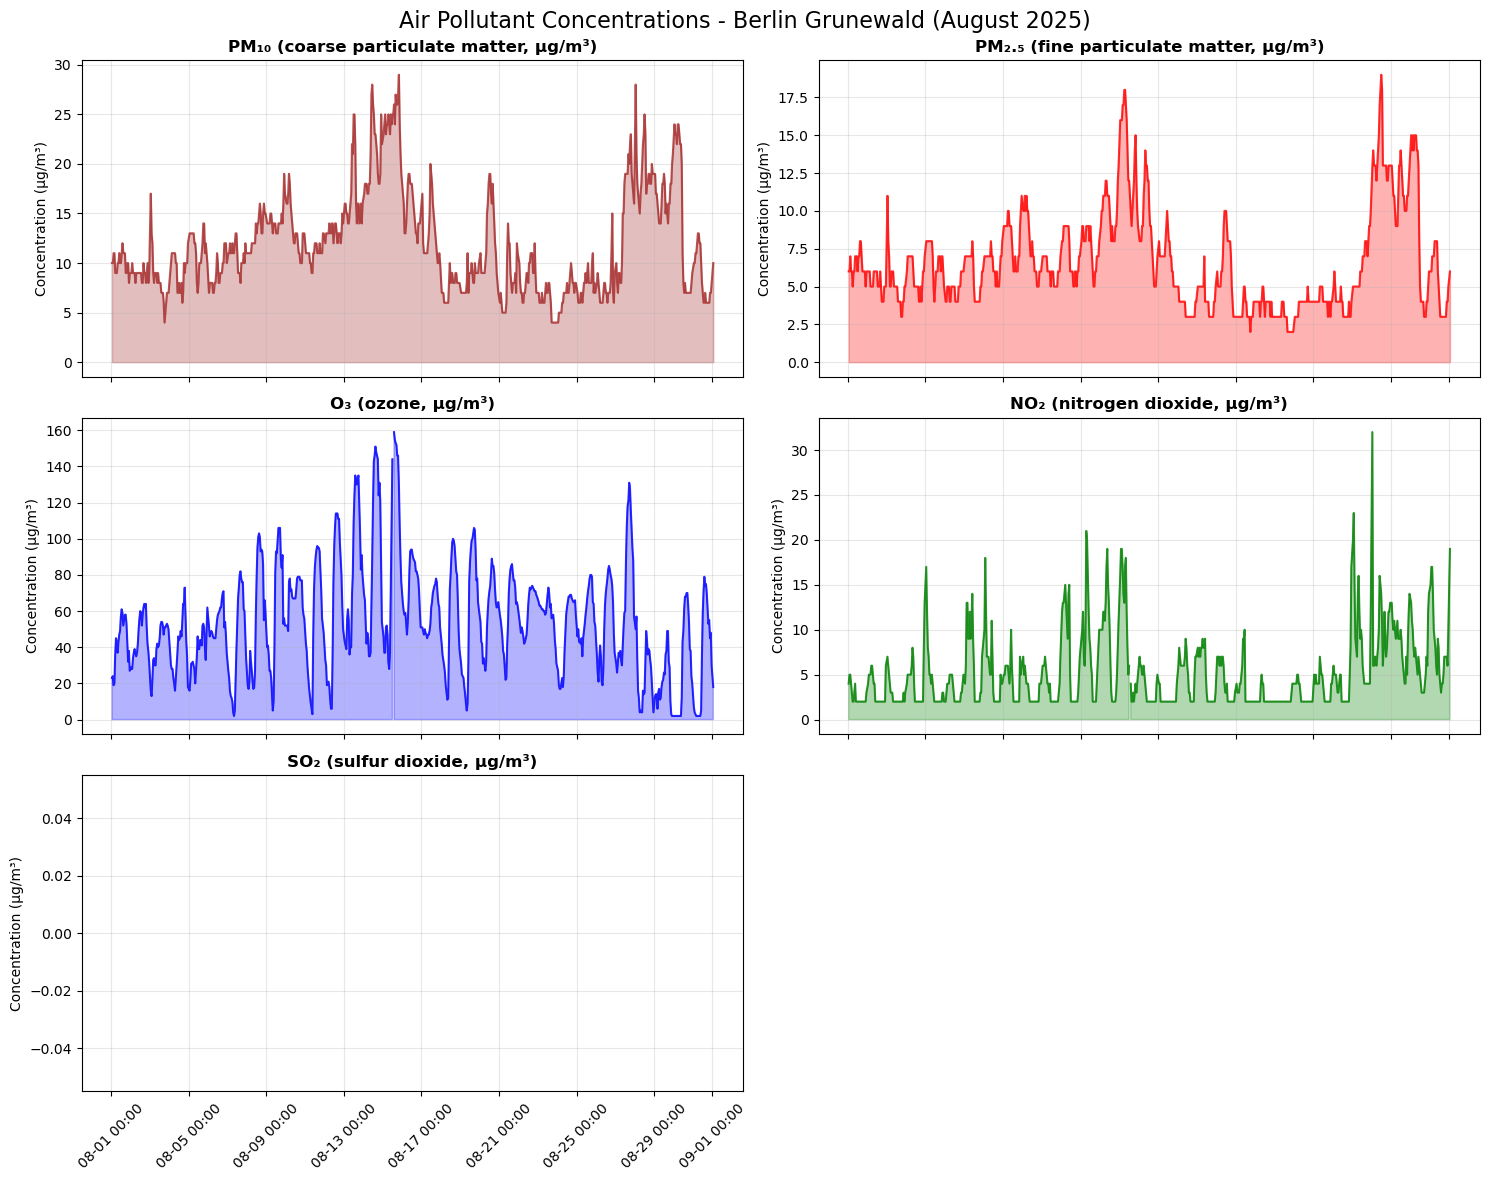

In [ ]:
# Set up the plotting style
plt.style.use('default')
plt.rcParams['figure.figsize'] = (12, 8)

# Create time series plot for pollutants
fig, axes = plt.subplots(3, 2, figsize=(15, 12), sharex=True)
fig.suptitle('Hourly air Pollutant Concentrations - Berlin Grunewald (August 2025)', fontsize=16)

# Define pollutant labels with chemical names
pollutant_labels = {
    'pm10': 'PM₁₀ (coarse particulate matter, µg/m³)',
    'pm25': 'PM₂.₅ (fine particulate matter, µg/m³)',
    'o3': 'O₃ (ozone, µg/m³)',
    'no2': 'NO₂ (nitrogen dioxide, µg/m³)',
    'so2': 'SO₂ (sulfur dioxide, µg/m³)'
}

# Plot each pollutant
pollutants = ['pm10', 'pm25', 'o3', 'no2', 'so2']
colors = ['brown', 'red', 'blue', 'green', 'orange']

for i, (pollutant, color) in enumerate(zip(pollutants, colors)):
    row, col = i // 2, i % 2
    ax = axes[row, col]
    
    # Plot the time series
    ax.plot(df['datetime'], df[pollutant], color=color, linewidth=1.5, alpha=0.8)
    ax.fill_between(df['datetime'], 0, df[pollutant], color=color, alpha=0.3)
    
    ax.set_title(pollutant_labels[pollutant], fontsize=12, fontweight='bold')
    ax.set_ylabel('Concentration (µg/m³)')
    ax.grid(True, alpha=0.3)
    
    # Format x-axis
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

# Remove empty subplot
axes[2, 1].remove()

plt.tight_layout()
plt.show()

#### 4.2 Distribution of AQI categories
 Here we understand the overall distribution of air quality categories. This bar chart provides a summary view of how frequently each AQI category (very good, good, moderate, poor, very poor) occurred during the August 2025 monitoring period at Berlin-Grunewald station.

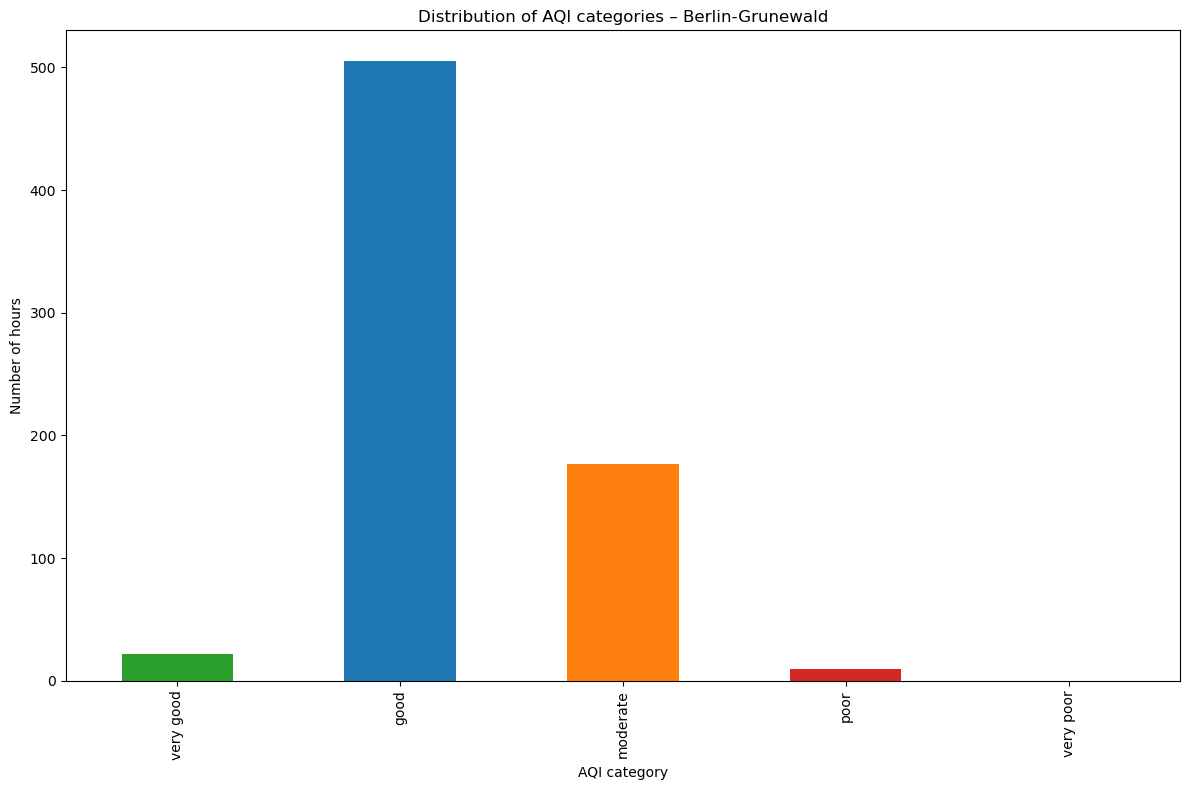

In [7]:
aqi_counts = df["aqi_computed"].value_counts().reindex(AQI_LEVELS)


colors = ["#2ca02c",   "#1f77b4",  "#ff7f0e",  "#d62728", "#9f27d6", "#7f7f7f"] 

ax = aqi_counts.plot(kind="bar", color=colors)
ax.set_xlabel("AQI category")
ax.set_ylabel("Number of hours")
ax.set_title("Distribution of AQI categories – Berlin-Grunewald")
plt.tight_layout()
plt.show()

#### 4.3 AQI heatmap (hour of day × date)
To get a more informative view of how air quality changes over time, we create a heatmap with:   
 - **x-axis:** date.  
 - **y-axis:** hour of day.   
 - **Color:** AQI category encoded as a discrete score.   
 - **AQI score** (1 = very good, …, 5 = very poor).  
 
This makes it easy to spot daily patterns, such as specific hours or days with worse air quality. The graph has been restricted to show only day time for readability.

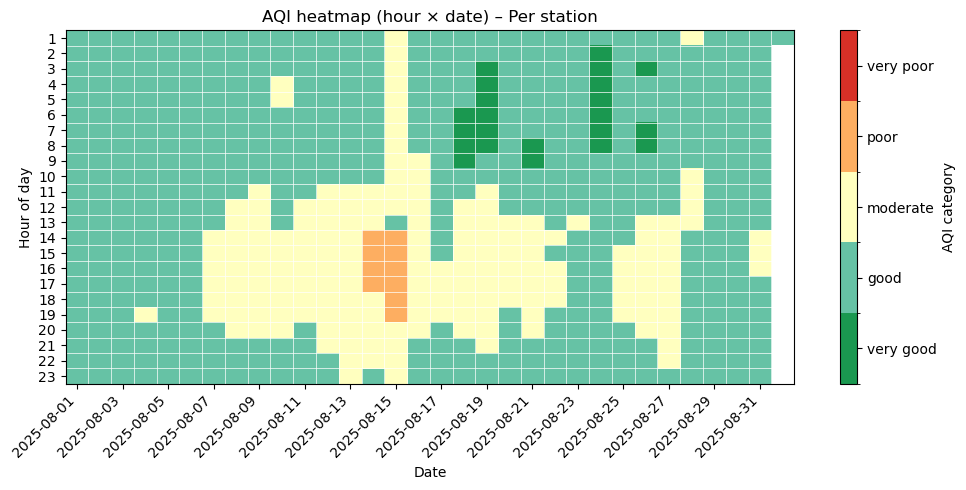

In [ ]:
df["date"] = df["datetime"].dt.date
df["hour"] = df["datetime"].dt.hour
df["aqi_score"] = df["aqi_computed"].map(AQI_SCORE)

# Pivot: hour × date, using mean AQI score
heat_data = (
    df.pivot_table(
        index="hour",
        columns="date",
        values="aqi_score",
        aggfunc="mean"
    )
    .sort_index(axis=0)
    .sort_index(axis=1)
)

heat_data = heat_data.loc[0:24]

# 1=very good, 2=good, 3=moderate, 4=poor, 5=very poor
colors = [
    "#1a9850",  
    "#66c2a5", 
    "#ffffbf",  
    "#fdae61", 
    "#d73027",  
]
cmap = ListedColormap(colors)
bounds = [0.5, 1.5, 2.5, 3.5, 4.5, 5.5]
norm = BoundaryNorm(bounds, cmap.N)

fig, ax = plt.subplots(figsize=(10, 5))

im = ax.imshow(
    heat_data.values,
    aspect="auto",
    interpolation="none",
    cmap=cmap,
    norm=norm,
)

n_dates = heat_data.shape[1]
all_dates = list(heat_data.columns)
tick_positions = list(range(0, n_dates, 2))  
ax.set_xticks(tick_positions)
ax.set_xticklabels([all_dates[i] for i in tick_positions], rotation=45, ha="right")

n_hours = heat_data.shape[0]
ax.set_yticks(np.arange(n_hours))
ax.set_yticklabels(list(heat_data.index))

ax.set_xlabel("Date")
ax.set_ylabel("Hour of day")
ax.set_title("AQI heatmap (hour × date) – Per station")
ax.set_xticks(np.arange(-0.5, n_dates, 1), minor=True)
ax.set_yticks(np.arange(-0.5, n_hours, 1), minor=True)
ax.grid(which="minor", color="white", linestyle="-", linewidth=0.5)
ax.tick_params(which="minor", bottom=False, left=False)

cbar = fig.colorbar(im, ax=ax, boundaries=bounds, ticks=[1, 2, 3, 4, 5])
cbar.ax.set_yticklabels(["very good", "good", "moderate", "poor", "very poor"])
cbar.set_label("AQI category")

plt.tight_layout()
plt.show()

## 5. Conclusion and Discussion

### Summary of Findings

In this computational analysis, we implemented and validated the German Air Quality Index (Luftqualitätsindex) calculation methodology using air quality monitoring data from the Berlin-Grunewald station for August 2025. Our implementation achieved perfect validation against official UBA reference values.

The analysis revealed that air quality at the Berlin-Grunewald monitoring station remained somehow consistent within the "good" category throughout the study period. Key pollutants monitored included fine particulate matter (PM₂.₅), ozone (O₃), and nitrogen dioxide (NO₂), with sulphur dioxide (SO₂) data unavailable for this specific station and time period.

### Discussion of Implications

The consistent "good" air quality classification during August 2025 suggests minimal acute health risks for the general population in the Berlin-Grunewald area. However, even within "good" categories, chronic exposure to pollutants like PM₂.₅ and O₃ can contribute to long term health effects including respiratory issues, cardiovascular disease, and reduced life expectancy. The absence of "moderate" or worse classifications during this summer period indicates effective local air quality management, though seasonal variations (particularly winter heating emissions) shows continued monitoring.

### Limitations and Future Directions

This analysis is limited by its focus on a single monitoring station and short temporal scope (one summer month) since it was for testing purposes. Spatial patterns across Berlin and seasonal variations remain unexplored. Future work should extend this analysis to:

- Multi station comparisons across urban Berlin using API calls for better automation of data loading
- Trend analysis over multiple years
- Integration with weather data to see the effects of the AQI on the weather
- Real time monitoring and alerting systems



## 6. References

### Primary Sources
1. **German Environment Agency (UBA)**. "The air quality index (Luftqualitätsindex)". Umweltbundesamt. Available at: https://www.umweltbundesamt.de/en/calculation-base-air-quality-index

2. **UBA Air Quality Data Portal**. Real-time and historical air quality monitoring data. Available at: https://luftdaten.umweltbundesamt.de

### Air Quality Standards and Guidelines
3. World Health Organization (WHO). "WHO global air quality guidelines: particulate matter (\u200EPM₂.₅ and PM₁₀)\u200E, ozone, nitrogen dioxide, sulfur dioxide and carbon monoxide". World Health Organization, 2021. Available at: https://www.who.int/publications/i/item/9789240034228

4. World Health Organization (WHO). "WHO Air quality guidelines for Europe, second edition". World Health Organization Regional Office for Europe, 2000. Available at: https://www.who.int/publications/i/item/9789289013581